In [28]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [24]:
(X_train, y_train), (X_test, y_test)=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
X_train.shape

(60000, 28, 28)

In [27]:
X_test.shape

(10000, 28, 28)

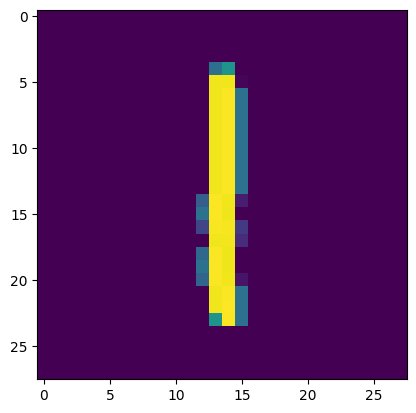

In [31]:
plt.imshow(X_train[102])
plt.show()

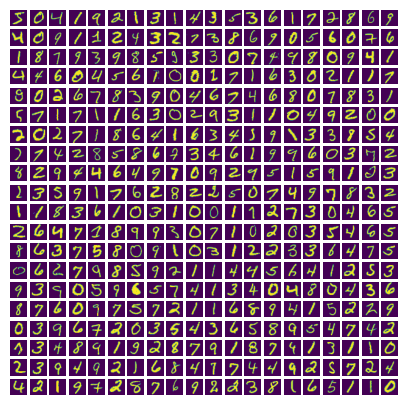

In [46]:
fig, ax=plt.subplots(20, 20, figsize=(5,5))
num=0
for i in range(0, 20, 1):
  for j in range(0, 20, 1):
    ax[i][j].imshow(X_train[num])
    ax[i][j].axis('off') # Turn off axis to make it cleaner
    num=num+1
plt.show()

In [65]:
model=Sequential()

model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation='relu', input_dim=784))
model.add(Dense(10,  activation='softmax'))

In [66]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam', metrics=['accuracy'])

In [69]:
history=model.fit(X_train, y_train, validation_split=0.2, epochs=20)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8553 - loss: 3.1666 - val_accuracy: 0.8881 - val_loss: 0.5846
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9033 - loss: 0.4397 - val_accuracy: 0.9184 - val_loss: 0.4138
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9236 - loss: 0.3267 - val_accuracy: 0.9324 - val_loss: 0.3133
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9348 - loss: 0.2630 - val_accuracy: 0.9241 - val_loss: 0.2985
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9411 - loss: 0.2359 - val_accuracy: 0.9268 - val_loss: 0.3286
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9455 - loss: 0.2211 - val_accuracy: 0.9435 - val_loss: 0.2277
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9476 - loss: 0.2143 - val_accuracy: 0.9362 - val_loss: 0.2645
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9529 - loss: 0.1938 -

In [71]:
y_prob=model.predict(X_test)
y_pred=y_prob.argmax(axis=1)
print("Accuracy: ",accuracy_score(y_test, y_pred) )
print("Precision: ",precision_score(y_test, y_pred, average='weighted') )
print("Recall: ",recall_score(y_test, y_pred, average='weighted') )

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy:  0.947
Precision:  0.9484252983209198
Recall:  0.947


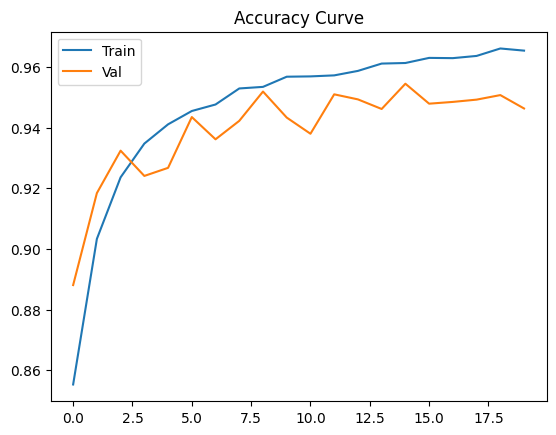

In [72]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend();
plt.title("Accuracy Curve")
plt.show()

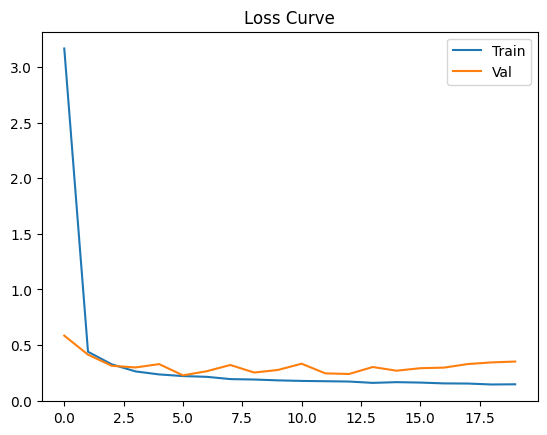

In [73]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend();
plt.title("Loss Curve")
plt.show()